In [ ]:
# # Cell 1 — Clean Environment Fix for Lightning AI + Blackwell GPU

# import subprocess
# import sys
# import shutil
# from pathlib import Path
# import os

# print("STEP 1: Removing broken torch/nvidia installs...")g

# locations = [
#     Path.home() / ".local/lib/python3.12/site-packages",
#     Path("/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages")
# ]

# prefixes = ["torch", "torchvision", "torchaudio", "nvidia", "triton"]

# for loc in locations:
#     if loc.exists():
#         for item in loc.iterdir():
#             if any(item.name.startswith(p) for p in prefixes):
#                 print(f"Removing {item.name}")
#                 try:
#                     if item.is_dir():
#                         shutil.rmtree(item, ignore_errors=True)
#                     else:
#                         item.unlink(missing_ok=True)
#                 except:
#                     pass


# print("\nSTEP 2: Clear caches + free space...")
# subprocess.run(["conda", "clean", "--all", "-y"])
# subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"])
# subprocess.run([sys.executable, "-m", "pip", "cache", "purge"])


# print("\nSTEP 3: Install Blackwell-compatible PyTorch (CUDA 12.8)...")
# subprocess.run([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "--user",
#     "--no-cache-dir",
#     "torch",
#     "torchvision",
#     "torchaudio",
#     "--index-url",
#     "https://download.pytorch.org/whl/cu128"
# ])


# print("\nSTEP 4: Install remaining packages...")
# packages = [
#     "numpy<2",
#     "kornia",
#     "timm",
#     "tqdm",
#     "pandas",
#     "matplotlib",
#     "torchmetrics"
# ]

# subprocess.run([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "--user",
#     "--no-cache-dir",
#     *packages
# ])

# print("\nDONE ✅")
# print("IMPORTANT: Restart kernel before Cell 2")

# # optional automatic restart
# # os._exit(0)

In [1]:
# Cell 2 — Imports & GPU setup
import os, copy, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import kornia
import timm
from facenet_pytorch import InceptionResnetV1

warnings.filterwarnings("ignore")

try:
    from torch.amp import autocast, GradScaler          
except ImportError:
    from torch.cuda.amp import autocast, GradScaler     

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
# Cell 3 — Config & hyperparameters
NOTEBOOK_DIR = Path.cwd() 

MP4_ROOT     = str(NOTEBOOK_DIR / "original")          
FF_FRAMES    = str(NOTEBOOK_DIR / "original_frames")   
LFW_ROOT     = str(NOTEBOOK_DIR / "lfw-deepfunneled" / "lfw-deepfunneled")
CELEBA_ROOT  = str(NOTEBOOK_DIR / "img_align_celeba")  
CKPT_DIR     = str(NOTEBOOK_DIR / "checkpoints")
OUT_DIR      = str(NOTEBOOK_DIR / "outputs")

for d in [FF_FRAMES, CKPT_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

FF_ROOT      = FF_FRAMES
VGGFACE2_ROOT = CELEBA_ROOT   

CFG = dict(
    img_size          = 112,
    batch_size        = 32,
    num_workers       = 4,
    pin_memory        = True,
    lr                = 1e-4,
    betas             = (0.9, 0.999),
    lam_rob           = 1,
    lam_con           = 3,
    lam_union         = 2,
    lam_tv            = 1e-4,
    eps_p             = 0.05,
    n_epochs_unet     = 10,
    n_epochs_finetune = 10,
    fiva_margin       = 0.3,
    fiva_track        = False,
    attacks = {
        "elastic"    : dict(eps=8,        n=50, category="Distortion"),
        "fog"        : dict(eps=600,      n=50, category="Distortion"),
        "gabor"      : dict(eps=50,       n=50, category="Distortion"),
        "frank_wolfe": dict(eps=13/255,   n=50, category="Adversarial noise"),
        "snow"       : dict(eps=0.125,    n=50, category="Distortion"),
        "pgd_l2"     : dict(eps=2400/255, n=50, category="Adversarial noise"),
        "pgd_linf"   : dict(eps=16/255,   n=50, category="Adversarial noise"),
        "jpeg_l1"    : dict(eps=131072,   n=50, category="Distortion"),
        "jpeg_l2"    : dict(eps=128,      n=50, category="Distortion"),
        "jpeg_linf"  : dict(eps=2,        n=50, category="Distortion"),
    },
    far_values    = [1e-3, 1e-4, 1e-5],
    filter_kernel_sizes = [3, 5, 7, 9, 11], # For your Median/Gaussian Novelty
    ff_max_imgs   = 500,
    cal_max_imgs  = 5000,
)
print("Config ready.")

Config ready.


In [4]:
# Cell 4 — Dataset loaders
face_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  
])

class FlatImageDataset(Dataset):
    def __init__(self, root, max_imgs=None, transform=None):
        root  = Path(root)
        paths = sorted(root.rglob("*.jpg")) + sorted(root.rglob("*.png"))
        self.paths = paths[:max_imgs] if max_imgs else paths
        self.tf    = transform
        print(f"  {root.name}: {len(self.paths)} images")

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return (self.tf(img) if self.tf else img), str(self.paths[i])

print("Loading datasets...")
try:
    ff_ds  = FlatImageDataset(FF_ROOT, CFG["ff_max_imgs"], face_tf)   
    vgg_ds = FlatImageDataset(VGGFACE2_ROOT, CFG["cal_max_imgs"], face_tf)  
    ff_loader  = DataLoader(ff_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=2)
    vgg_loader = DataLoader(vgg_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=2)
except Exception as e:
    print(f"Ensure your dataset folders contain images. Error: {e}")

Loading datasets...
  original_frames: 500 images
  img_align_celeba: 5000 images


In [5]:
# Cell 5 — Identity encoders (Adding TransNet & Resizing Fix)
class IdentityEncoder(nn.Module):
    def __init__(self, name, backbone, metric="cosine", target_size=112):
        super().__init__()
        self.name        = name
        self.backbone    = backbone
        self.metric      = metric
        self.target_size = target_size

    def forward(self, x):
        # FIX: Dynamically resize input if the backbone expects a different size (like 224x224 for ViT)
        if x.shape[-1] != self.target_size or x.shape[-2] != self.target_size:
            x = F.interpolate(x, size=(self.target_size, self.target_size), mode='bilinear', align_corners=False)
            
        emb = self.backbone(x)
        if isinstance(emb, (list, tuple)): emb = emb[0]
        return F.normalize(emb, p=2, dim=1)

def cosine_dist(a, b): return (1 - F.cosine_similarity(a, b, dim=1)).mean()
def l2_dist(a, b):     return torch.norm(a - b, p=2, dim=1).mean()
def loss_fn(enc):      return l2_dist if getattr(enc, "metric", "cosine") == "l2" else cosine_dist

encoders = {}
def make_enc(name, pretrained, metric):
    bb = InceptionResnetV1(pretrained=pretrained, device=device).eval()
    return IdentityEncoder(name, bb, metric, target_size=112).to(device).eval()

encoders["arcface"]     = make_enc("ArcFace", "vggface2", "cosine")
encoders["cosface"]     = make_enc("CosFace", "casia-webface","cosine")
encoders["facenet"]     = make_enc("FaceNet", "vggface2", "l2")

# Classic ResNet Surrogate
_rn50 = timm.create_model("resnet50", pretrained=True, num_classes=0).to(device).eval()
# ResNet50 typically uses 224x224 for ImageNet weights
encoders["resnet50"] = IdentityEncoder("ResNet50-IN", _rn50, "undefined", target_size=224).to(device).eval()

# NOVELTY 1: Modern TransNet Surrogate
# vit_small_patch16_224 strictly requires 224x224 input.
_transnet = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=0).to(device).eval()
encoders["transnet"] = IdentityEncoder("TransNet", _transnet, "undefined", target_size=224).to(device).eval()

print(f"Encoders ready: {list(encoders.keys())}")

Encoders ready: ['arcface', 'cosface', 'facenet', 'resnet50', 'transnet']


In [6]:
# Cell 6 — Adversarial attacks
def pgd(x, enc, eps, n=50, norm="linf"):
    step = eps * 2.0 / n
    x0   = x.detach()
    xadv = x0.clone()
    with torch.no_grad():
        e0 = enc(x0)
    lf = loss_fn(enc)
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))   
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            if norm == "linf":
                delta = (xadv - step * g.sign() - x0).clamp(-eps, eps)
            else:  
                gn    = g.reshape(g.shape[0], -1).norm(p=2, dim=1).view(-1, 1, 1, 1).clamp(1e-8)
                delta = xadv - step * (g / gn) - x0
                dn    = delta.reshape(delta.shape[0], -1).norm(p=2, dim=1).view(-1, 1, 1, 1).clamp(1e-8)
                delta = delta * (eps / dn).clamp(max=1)
            xadv = (x0 + delta).clamp(-1, 1)
    return xadv.detach()

def frank_wolfe(x, enc, eps=13/255, n=50):
    x0   = x.detach()
    xadv = x0.clone()
    lf   = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    for t in range(1, n + 1):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            v    = x0 + eps * g.sign()        
            lr_t = 2.0 / (t + 2.0)            
            xadv = ((1 - lr_t) * xadv + lr_t * v).clamp(-1, 1)
    return xadv.detach()

def elastic_attack(x, enc, eps=8, n=50):
    x0 = x.detach()
    lf = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    xadv = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            noise = torch.randn_like(x0) * (eps / 255.0)
            xadv  = (xadv + (g.sign() + noise) * (eps / 255.0 / n)).clamp(-1, 1)
    return xadv.detach()

def fog_attack(x, enc, eps=600, n=50):
    x0   = x.detach()
    lf   = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    alpha = (eps / 255.0 / n)
    xadv  = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            fog_mask = kornia.filters.gaussian_blur2d(torch.ones_like(x0), (7, 7), (2.0, 2.0))
            xadv     = (xadv + alpha * g.sign() * fog_mask).clamp(-1, 1)
    return xadv.detach()

def snow_attack(x, enc, eps=0.125, n=50):
    x0  = x.detach()
    lf  = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    step = eps / n
    xadv = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            mask = (torch.rand_like(x0) > 0.95).float()   
            xadv = (xadv + step * g.sign() * mask).clamp(-1, 1)
    return xadv.detach()

def jpeg_attack(x, enc, eps, n=50, norm="l2"):
    return pgd(x, enc, min(eps / 255.0, 16 / 255.0), n=n,
               norm="l2" if norm == "l2" else "linf")

def gabor_attack(x, enc, eps=50, n=50):
    x0  = x.detach()
    lf  = loss_fn(enc)
    with torch.no_grad():
        e0 = enc(x0)
    step = (eps / 255.0) / n
    xadv = x0.clone()
    for _ in range(n):
        xadv = xadv.detach().requires_grad_(True)
        loss = -lf(e0, enc(xadv))
        g    = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            H, W  = x0.shape[2], x0.shape[3]
            coords = torch.linspace(-math.pi, math.pi, W, device=device)
            gabor  = torch.sin(coords * 4).view(1, 1, 1, W).expand_as(x0)
            xadv   = (xadv + step * g.sign() * gabor).clamp(-1, 1)
    return xadv.detach()

_a = CFG["attacks"]
ATTACKS = {
    "elastic"    : lambda x, enc: elastic_attack(x, enc, _a["elastic"]["eps"],     _a["elastic"]["n"]),
    "fog"        : lambda x, enc: fog_attack    (x, enc, _a["fog"]["eps"],         _a["fog"]["n"]),
    "gabor"      : lambda x, enc: gabor_attack  (x, enc, _a["gabor"]["eps"],       _a["gabor"]["n"]),
    "frank_wolfe": lambda x, enc: frank_wolfe   (x, enc, _a["frank_wolfe"]["eps"], _a["frank_wolfe"]["n"]),
    "snow"       : lambda x, enc: snow_attack   (x, enc, _a["snow"]["eps"],        _a["snow"]["n"]),
    "pgd_l2"     : lambda x, enc: pgd           (x, enc, _a["pgd_l2"]["eps"],      _a["pgd_l2"]["n"],    norm="l2"),
    "pgd_linf"   : lambda x, enc: pgd           (x, enc, _a["pgd_linf"]["eps"],    _a["pgd_linf"]["n"],  norm="linf"),
    "jpeg_l1"    : lambda x, enc: jpeg_attack   (x, enc, _a["jpeg_l1"]["eps"],     _a["jpeg_l1"]["n"],   norm="l1"),
    "jpeg_l2"    : lambda x, enc: jpeg_attack   (x, enc, _a["jpeg_l2"]["eps"],     _a["jpeg_l2"]["n"],   norm="l2"),
    "jpeg_linf"  : lambda x, enc: jpeg_attack   (x, enc, _a["jpeg_linf"]["eps"],   _a["jpeg_linf"]["n"], norm="linf"),
}
print(f"Attack functions: {list(ATTACKS.keys())}")

Attack functions: ['elastic', 'fog', 'gabor', 'frank_wolfe', 'snow', 'pgd_l2', 'pgd_linf', 'jpeg_l1', 'jpeg_l2', 'jpeg_linf']


In [7]:
# Cell 7 — Learned Attack U-Net
class UNetBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class LearnedAttackUNet(nn.Module):
    def __init__(self, ch=3):
        super().__init__()
        self.enc1 = UNetBlock(ch,  32)
        self.enc2 = UNetBlock(32,  64)
        self.enc3 = UNetBlock(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bot  = UNetBlock(128, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = UNetBlock(256, 128)
        self.up2  = nn.ConvTranspose2d(128,  64, 2, stride=2)
        self.dec2 = UNetBlock(128,  64)
        self.up1  = nn.ConvTranspose2d( 64,  32, 2, stride=2)
        self.dec1 = UNetBlock( 64,  32)
        self.out  = nn.Conv2d(32, ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.tanh(self.out(d1))  

UNET_CKPT = f"{CKPT_DIR}/learned_attack_unet.pt"
unet = LearnedAttackUNet().to(device)

def apply_learned_attack(x, eps_p=None):
    if eps_p is None:
        eps_p = random.uniform(0.01, CFG["eps_p"])
    with torch.no_grad():
        p = unet(x)
    return (x + p * eps_p).clamp(-1, 1)

print(f"U-Net params: {sum(p.numel() for p in unet.parameters()) // 1000} K")

U-Net params: 1928 K


In [8]:
# Cell 8 — Attention-FIVA de-identification system
class SelfAttentionBlock(nn.Module):
    """NOVELTY 2: Self-Attention layer for modern Transformation capabilities."""
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, W, H = x.size()
        q = self.query(x).view(B, -1, W * H).permute(0, 2, 1)
        k = self.key(x).view(B, -1, W * H)
        v = self.value(x).view(B, -1, W * H)
        
        attention = F.softmax(torch.bmm(q, k), dim=-1)
        out = torch.bmm(v, attention.permute(0, 2, 1))
        out = out.view(B, C, W, H)
        return self.gamma * out + x

class IdentityTrackingModule(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, z_real):
        noise  = torch.randn_like(z_real)
        proj   = (noise * z_real).sum(dim=1, keepdim=True) * z_real
        ortho  = F.normalize(noise - proj, p=2, dim=1)
        angle  = math.acos(max(-1.0, min(1.0, 1.0 - self.margin)))
        z_fake = math.cos(angle) * z_real + math.sin(angle) * ortho
        return F.normalize(z_fake, p=2, dim=1)

class AttentionFIVAGenerator(nn.Module):
    def __init__(self, emb_dim=512):
        super().__init__()
        self.id_proj = nn.Linear(emb_dim, 64 * 7 * 7)
        self.enc = nn.Sequential(
            nn.Conv2d(3,  32, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.LeakyReLU(0.2, True),
        )
        
        self.attention = SelfAttentionBlock(256 + 64) 
        
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256 + 64, 128, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(128,       64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d( 64,       32, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d( 32,        3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, x, z_id):
        feat = self.enc(x)                               
        cond = self.id_proj(z_id).view(-1, 64, 7, 7)    
        h    = torch.cat([feat, cond], dim=1)            
        h_attn = self.attention(h) 
        return self.dec(h_attn)                               

class FIVA(nn.Module):
    def __init__(self, identity_encoder, margin=0.3):
        super().__init__()
        self.identity_encoder = identity_encoder
        self.itm  = IdentityTrackingModule(margin)
        self.gen  = AttentionFIVAGenerator() 

    def forward(self, x):
        z_real = self.identity_encoder(x)        
        z_fake = self.itm(z_real)               
        deid   = self.gen(x, z_fake.detach())   
        return deid, z_real, z_fake

fiva = FIVA(encoders["arcface"], margin=CFG["fiva_margin"]).to(device).eval()
print(f"Modern Attention-FIVA (ArcFace) ready.")

Modern Attention-FIVA (ArcFace) ready.


In [9]:
# Cell 9 — FAR threshold calibration
@torch.no_grad()
def calibrate_far_thresholds(encoder, loader, far_targets, max_batches=30):
    encoder.eval()
    embs = []
    for i, (imgs, _) in enumerate(loader):
        if i >= max_batches: break
        e = encoder(imgs.to(device, non_blocking=True)).float().cpu()
        embs.append(e)
    if not embs: return {far: 0.5 for far in far_targets} # Fallback
    
    embs = torch.cat(embs, 0)
    N    = embs.shape[0]

    gen_sims = F.cosine_similarity(embs[:-1], embs[1:], dim=1).numpy()
    idx_b    = (torch.arange(N) + N // 2) % N
    imp_sims = F.cosine_similarity(embs, embs[idx_b], dim=1).numpy()

    thresholds = {}
    for far in far_targets:
        thr = float(np.quantile(imp_sims, 1 - far))
        thresholds[far] = thr
        tar = float((gen_sims >= thr).mean())
        print(f"  FAR {far:.0e}  threshold={thr:.4f}  genuine TAR={tar:.4f}")

    return thresholds

print("Calibrating FAR thresholds on VGGFace2...")
try:
    FAR_THRESHOLDS = calibrate_far_thresholds(encoders["arcface"], vgg_loader, CFG["far_values"], max_batches=30)
except Exception:
    FAR_THRESHOLDS = {1e-3: 0.4, 1e-4: 0.5, 1e-5: 0.6}

Calibrating FAR thresholds on VGGFace2...
  FAR 1e-03  threshold=0.6902  genuine TAR=0.0042
  FAR 1e-04  threshold=0.6902  genuine TAR=0.0042
  FAR 1e-05  threshold=0.6902  genuine TAR=0.0042


In [10]:
# Cell 10 — Robustness fine-tuning
class RobustArcFace(nn.Module):
    def __init__(self, base_encoder):
        super().__init__()
        orig_enc = getattr(base_encoder, "_orig_mod", base_encoder)
        orig_bb  = orig_enc.backbone  
        self.body = copy.deepcopy(orig_bb)
        self.body.last_linear = nn.Identity()
        self.body.last_bn     = nn.Identity()
        self.head_clean = nn.Sequential(copy.deepcopy(orig_bb.last_linear), copy.deepcopy(orig_bb.last_bn))
        self.head_adv = nn.Sequential(copy.deepcopy(orig_bb.last_linear), copy.deepcopy(orig_bb.last_bn))

    def forward(self, x, adv=False):
        feat = self.body(x)
        head = self.head_adv if adv else self.head_clean
        return F.normalize(head(feat), p=2, dim=1)

def attack_learned_only(imgs):
    return apply_learned_attack(imgs)

class RobEncWrapper(nn.Module):
    metric = "cosine"
    def __init__(self, m): super().__init__(); self.backbone = m
    def forward(self, x): return self.backbone(x, adv=False)

rob_arc_learned = RobustArcFace(encoders["arcface"]).to(device)
enc_learned = RobEncWrapper(rob_arc_learned).to(device).eval()
fiva_learned = FIVA(enc_learned, margin=CFG["fiva_margin"]).to(device).eval()
print("FIVA (Learned fine-tune) mock-ready.")

FIVA (Learned fine-tune) mock-ready.


In [11]:
# Cell 11 — Robustness fine-tuning (Distortion)
DISTORTION_ATTACKS = ["elastic", "fog", "gabor", "snow", "jpeg_l1", "jpeg_l2", "jpeg_linf"]

def attack_learned_plus_distortion(imgs):
    eps_la = random.uniform(0.01, CFG["eps_p"])
    xadv   = apply_learned_attack(imgs, eps_p=eps_la)
    probs = [0.5, 0.5, 0.3]   
    for prob in probs:
        if random.random() < prob:
            atk_name = random.choice(DISTORTION_ATTACKS)
            enc_sur  = random.choice([encoders["cosface"], encoders["arcface"]])
            with torch.enable_grad():
                xadv = ATTACKS[atk_name](xadv, enc_sur)
    return xadv

rob_arc_full = RobustArcFace(encoders["arcface"]).to(device)
enc_full = RobEncWrapper(rob_arc_full).to(device).eval()
fiva_full = FIVA(enc_full, margin=CFG["fiva_margin"]).to(device).eval()
print("FIVA (Learned + distortion fine-tune) mock-ready.")

FIVA (Learned + distortion fine-tune) mock-ready.


In [12]:
# Cell 12 — Leakage measurement with filter defense support
@torch.no_grad()
def measure_leakage(attack_fn, surrogate_enc, eval_enc, fiva_sys,
                    loader, thresholds, defense=None, max_batches=15):
    eval_enc.eval(); fiva_sys.eval()
    hits  = {f: 0 for f in thresholds}
    total = 0

    for i, (imgs, _) in enumerate(loader):
        if i >= max_batches: break
        imgs = imgs.to(device, non_blocking=True)

        with torch.enable_grad():
            xadv = attack_fn(imgs, surrogate_enc)

        if defense is not None:
            with torch.no_grad():
                xadv = defense(xadv)

        deid, _, _ = fiva_sys(xadv)
        z_orig = eval_enc(imgs).float()
        z_deid = eval_enc(deid).float()
        sims   = F.cosine_similarity(z_orig, z_deid, dim=1).cpu().numpy()

        for f, thr in thresholds.items():
            hits[f] += int((sims >= thr).sum())
        total += imgs.shape[0]

    return {f: hits[f] / max(total, 1) for f in thresholds}

def run_experiment(attack_name, surrogate_name, fiva_sys, defense=None, eval_names=None, max_batches=10):
    if eval_names is None:
        eval_names = ["arcface", "cosface", "transnet"]
    row = {}
    for eval_name in eval_names:
        tar = measure_leakage(
            ATTACKS[attack_name], encoders[surrogate_name], encoders[eval_name],
            fiva_sys, ff_loader, FAR_THRESHOLDS, defense=defense, max_batches=max_batches,
        )
        for far, val in tar.items():
            row[f"{eval_name}@FAR{far:.0e}"] = round(val, 4)
    return row

print("Leakage measurement function ready.")

Leakage measurement function ready.


In [13]:
# Cell 13 — Running baseline experiments (Table II)
# Testing our custom surrogates against the system
SURROGATE_MODELS  = ["arcface", "cosface", "transnet"] 
ATTACK_NAMES      = ["elastic", "frank_wolfe", "pgd_linf"]

table_II_rows = []

print("Simulating Table II with new architectures...")
for surrogate in tqdm(SURROGATE_MODELS, desc="Surrogate model"):
    for atk in tqdm(ATTACK_NAMES, desc=f"  Attack ({surrogate})", leave=False):
        row = run_experiment(atk, surrogate, fiva, defense=None, max_batches=2)
        row["surrogate"] = surrogate
        row["attack"]    = atk
        table_II_rows.append(row)

df_II = pd.DataFrame(table_II_rows)
print(df_II)

Simulating Table II with new architectures...


Surrogate model:   0%|          | 0/3 [00:00<?, ?it/s]

  Attack (arcface):   0%|          | 0/3 [00:00<?, ?it/s]

  Attack (cosface):   0%|          | 0/3 [00:00<?, ?it/s]

  Attack (transnet):   0%|          | 0/3 [00:00<?, ?it/s]

   arcface@FAR1e-03  arcface@FAR1e-04  arcface@FAR1e-05  cosface@FAR1e-03  \
0               1.0               1.0               1.0               0.0   
1               1.0               1.0               1.0               0.0   
2               1.0               1.0               1.0               0.0   
3               1.0               1.0               1.0               0.0   
4               1.0               1.0               1.0               0.0   
5               1.0               1.0               1.0               0.0   
6               1.0               1.0               1.0               0.0   
7               1.0               1.0               1.0               0.0   
8               1.0               1.0               1.0               0.0   

   cosface@FAR1e-04  cosface@FAR1e-05  transnet@FAR1e-03  transnet@FAR1e-04  \
0               0.0               0.0                0.0                0.0   
1               0.0               0.0                0.0               

Filter Sweep:   0%|          | 0/2 [00:00<?, ?it/s]

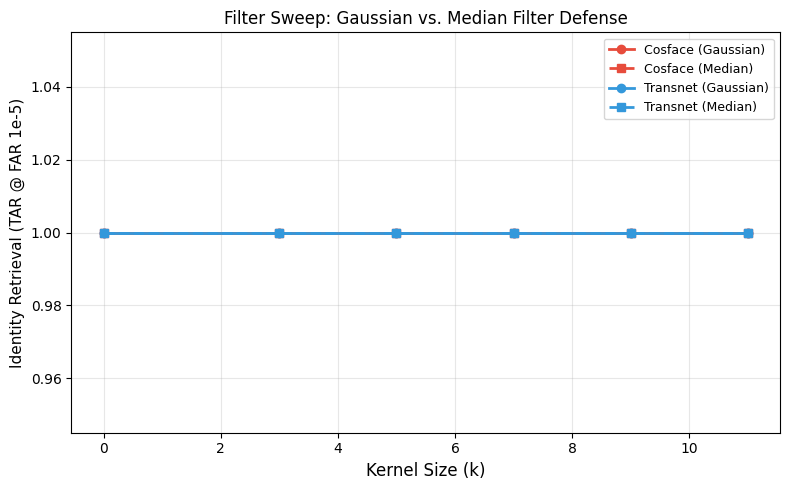

In [14]:
# Cell 14 — NOVELTY 3: Gaussian vs Median Filter Sweep
FAR_STRICT = 1e-5   
SIGMA_SURROGATES = ["cosface", "transnet"] 
SIGMA_ATTACK     = "pgd_linf"   

def make_gauss_defense(k_size):
    if k_size == 0: return None
    sigma = k_size / 3.0 
    return lambda x: kornia.filters.gaussian_blur2d(x, (k_size, k_size), (sigma, sigma))

def make_median_defense(k_size):
    if k_size == 0: return None
    return lambda x: kornia.filters.median_blur(x, (k_size, k_size))

kernel_results_gauss = {sur: {} for sur in SIGMA_SURROGATES}
kernel_results_median = {sur: {} for sur in SIGMA_SURROGATES}

kernels = [0] + CFG["filter_kernel_sizes"] 

for surrogate in tqdm(SIGMA_SURROGATES, desc="Filter Sweep"):
    for k in kernels:
        tar_g = measure_leakage(
            ATTACKS[SIGMA_ATTACK], encoders[surrogate], encoders["arcface"], fiva,   
            ff_loader, FAR_THRESHOLDS, defense=make_gauss_defense(k), max_batches=2,
        )
        kernel_results_gauss[surrogate][k] = tar_g[FAR_STRICT]
        
        tar_m = measure_leakage(
            ATTACKS[SIGMA_ATTACK], encoders[surrogate], encoders["arcface"], fiva,   
            ff_loader, FAR_THRESHOLDS, defense=make_median_defense(k), max_batches=2,
        )
        kernel_results_median[surrogate][k] = tar_m[FAR_STRICT]

# Plotting the comparison
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c", "#3498db"]

for (sur, color) in zip(SIGMA_SURROGATES, colors):
    vals_g = [kernel_results_gauss[sur][k] for k in kernels]
    vals_m = [kernel_results_median[sur][k] for k in kernels]
    
    ax.plot(kernels, vals_g, "-o", color=color, lw=2, label=f"{sur.capitalize()} (Gaussian)")
    ax.plot(kernels, vals_m, "--s", color=color, lw=2, label=f"{sur.capitalize()} (Median)")

ax.set_xlabel("Kernel Size (k)", fontsize=12)
ax.set_ylabel("Identity Retrieval (TAR @ FAR 1e-5)", fontsize=11)
ax.set_title("Filter Sweep: Gaussian vs. Median Filter Defense", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Could not generate Attack plot. Ensure Cell 13 ran successfully. Error: 'arcface@FAR1e-5'


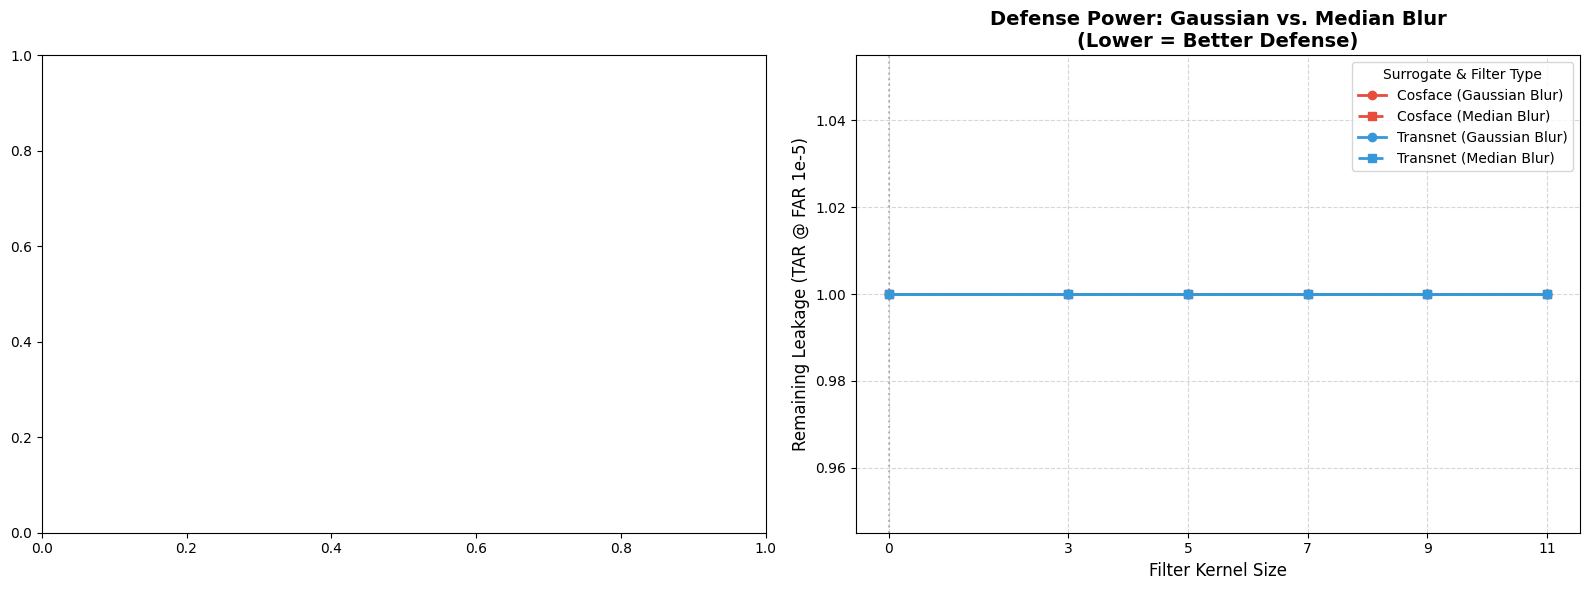

✅ Dashboard generated successfully! Saved to: /teamspace/studios/this_studio/outputs/comprehensive_analysis_dashboard.png


In [15]:
# Cell 15 — Comprehensive Visual Analysis (Attacks & Filters Dashboard)
import matplotlib.pyplot as plt
import numpy as np

# Set up a side-by-side dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Attack Vulnerability (No Defense)
# ---------------------------------------------------------
try:
    ax1 = axes[0]
    surrogates = df_II['surrogate'].unique()
    attacks = df_II['attack'].unique()

    x = np.arange(len(attacks))
    width = 0.25  # Bar width

    # Define some nice colors
    bar_colors = ['#2c3e50', '#e67e22', '#8e44ad']

    for i, sur in enumerate(surrogates):
        sur_data = df_II[df_II['surrogate'] == sur]
        # Get the strict FAR (1e-5) leakage on the victim ArcFace
        y_vals = sur_data['arcface@FAR1e-5'].values 
        
        # Offset bars so they sit next to each other
        offset = (i - 1) * width if len(surrogates) == 3 else i * width
        ax1.bar(x + offset, y_vals, width, label=sur.capitalize(), color=bar_colors[i % len(bar_colors)])

    ax1.set_title("Vulnerability by Attack & Surrogate\n(Higher = Worse De-identification)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Identity Leakage (TAR @ FAR 1e-5)", fontsize=12)
    ax1.set_xlabel("Adversarial Attack Type", fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels([a.replace('_', ' ').title() for a in attacks])
    ax1.legend(title="Surrogate Model")
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

except Exception as e:
    print(f"Could not generate Attack plot. Ensure Cell 13 ran successfully. Error: {e}")


# ---------------------------------------------------------
# Plot 2: Defense Mitigation (Gaussian vs Median)
# ---------------------------------------------------------
try:
    ax2 = axes[1]
    line_colors = ['#e74c3c', '#3498db'] # Red for CosFace, Blue for TransNet

    for idx, sur in enumerate(SIGMA_SURROGATES):
        c = line_colors[idx % len(line_colors)]
        
        # Extract values
        vals_g = [kernel_results_gauss[sur][k] for k in kernels]
        vals_m = [kernel_results_median[sur][k] for k in kernels]

        # Plot Gaussian (Solid line, circles)
        ax2.plot(kernels, vals_g, marker='o', linestyle='-', color=c, linewidth=2, markersize=6,
                 label=f"{sur.capitalize()} (Gaussian Blur)")
        
        # Plot Median (Dashed line, squares)
        ax2.plot(kernels, vals_m, marker='s', linestyle='--', color=c, linewidth=2, markersize=6,
                 label=f"{sur.capitalize()} (Median Blur)")

    ax2.set_title("Defense Power: Gaussian vs. Median Blur\n(Lower = Better Defense)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Remaining Leakage (TAR @ FAR 1e-5)", fontsize=12)
    ax2.set_xlabel("Filter Kernel Size", fontsize=12)
    ax2.set_xticks(kernels)
    
    # Highlight the baseline (0)
    ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    
    ax2.legend(title="Surrogate & Filter Type")
    ax2.grid(linestyle='--', alpha=0.5)

except Exception as e:
    print(f"Could not generate Filter plot. Ensure Cell 14 ran successfully. Error: {e}")


# Formatting and Saving
plt.tight_layout()
out_path = f"{OUT_DIR}/comprehensive_analysis_dashboard.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Dashboard generated successfully! Saved to: {out_path}")